# Вариант 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)

A data set contains 21613 obervations with 19 features plus house price. The names of the columns are given below.

- **id**
- **date**: Date house was sold
- **price**: Price of the sold house
- **bedrooms**: Number of bedrooms
- **bathrooms**: Number of bathrooms
- **sqft_living**: Square footage of the apartment interior living space
- **sqrt_lot**: Square footage of the lot
- **floors**: Number of floors
- **waterfront**: Whether the house has a view on a waterfront (1: yes, 0: not)
- **view**: A rate from 0 to 4 of how good the view of the property was
- **condition**: A rate from 1 to 5 on the condition of the apartment
- **grade**: A rate from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high-quality level of construction and design
- **sqft_above**: Square footage of house apart from basement
- **sqft_basement**: Square footage of the basement
- **yr_built**: The year the house was initially built
- **yr_renovated**: Year when the house was renovated
- **zipcode**: What zipcode area the house is in
- **lat**: Latitude coordinate
- **long**: Longitude coordinate
- **sqft_living15**: The square footage of interior housing living space for the nearest 15 neighbors (or Living room area in 2015(implies some renovations))
- **sqrt_lot15**: The square footage of the land lots of the nearest 15 neighbors (or Lot area in 2015(implies some renovations))

In [88]:
data = pd.read_csv("kc_house_data.csv")
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# Задание 1


$H_0:~boxcox\_price~\sim \mathcal{N}(\mu, \sigma), \mu \in \mathbb{R}, \sigma \in \mathbb{R}^+$

$H_1: else$

In [139]:
from scipy.stats import boxcox

data["log_price"] = np.log(data["price"])
boxcox_price, lambda_opt = boxcox(data["price"])
data["boxcox_price"] = boxcox_price

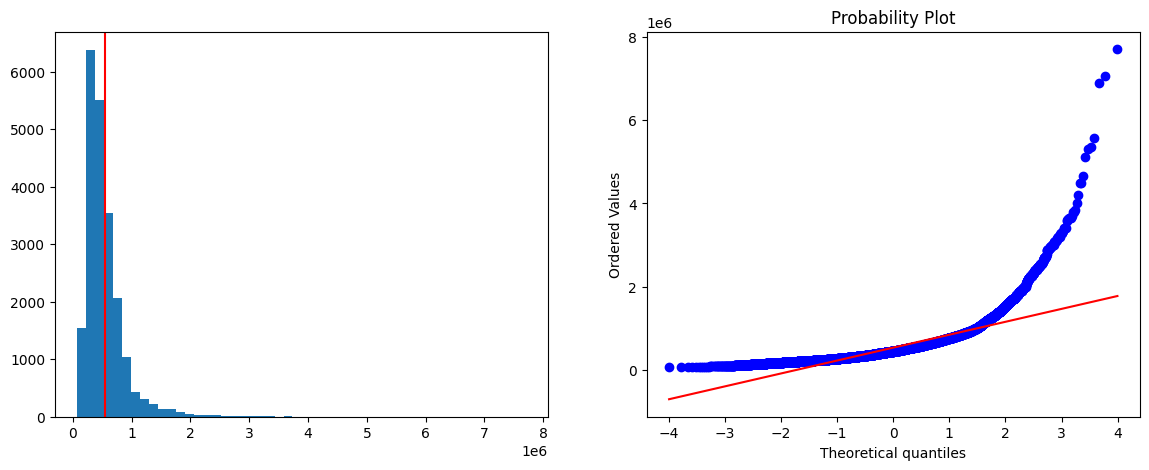

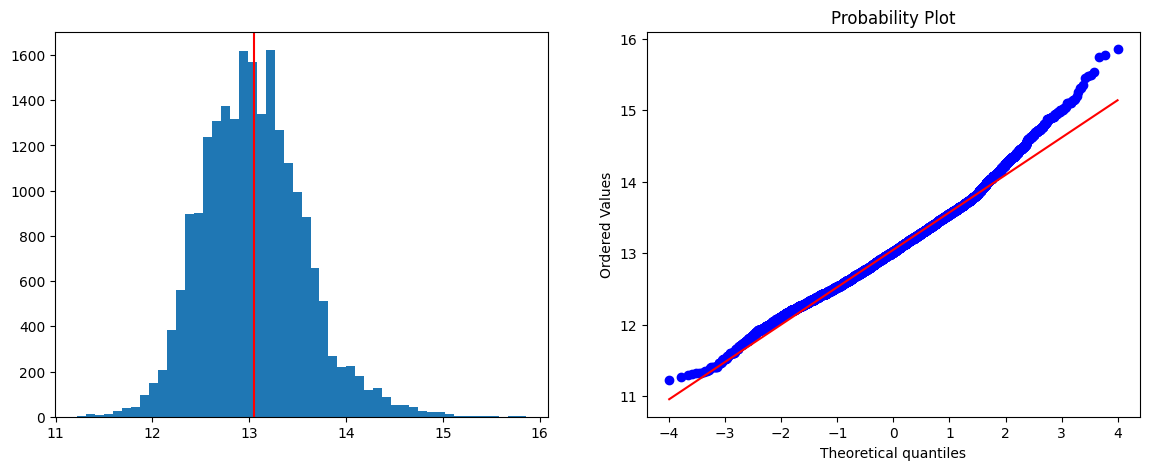

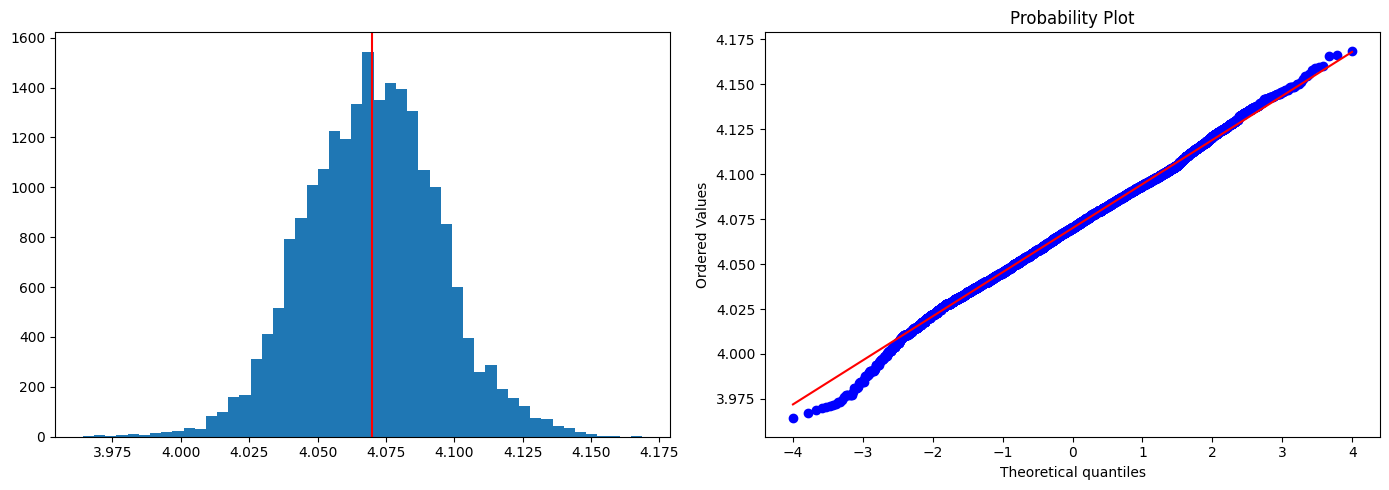

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data["price"], bins=50)
axes[0].axvline(data["price"].mean(), color="red")
stats.probplot(data["price"], dist="norm", plot=axes[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data["log_price"], bins=50)
axes[0].axvline(data["log_price"].mean(), color="red")
stats.probplot(data["log_price"], dist="norm", plot=axes[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(data["boxcox_price"], bins=50)
axes[0].axvline(data["boxcox_price"].mean(), color="red")
stats.probplot(data["boxcox_price"], dist="norm", plot=axes[1])

plt.tight_layout()
plt.show()

![](kolmogorov.png)

![](pvalue.png)

![](K.png)

In [147]:
def kolmogorov_smirnov_test(data, cdf_func, correction=False):
    n = len(data)
    cdfvals = cdf_func(np.sort(data))
    d_plus = (np.arange(1, n + 1) / n - cdfvals).max()
    d_minus = (cdfvals - np.arange(n) / n).max()
    d_n = max(d_plus, d_minus)
    z = d_n * np.sqrt(n)
    if correction:
        z += 1 / (6 * np.sqrt(n))
    p_value = 0
    for k in range(1, 101):
        p_value += 2 * (-1) ** (k - 1) * np.exp(-2 * k**2 * z**2)

    return d_n, np.clip(p_value, 0, 1), stats.ksone.ppf(0.95, n)

Не сразу понял что этот тест не подходит для сложной гипотезы, поэтому дальше параметрическая модификация

In [148]:
norm_cdf = lambda x: stats.norm.cdf(
    x, loc=data["boxcox_price"].mean(), scale=data["boxcox_price"].std(ddof=1)
)
print(
    kolmogorov_smirnov_test(data["boxcox_price"], cdf_func=norm_cdf)
)  # так делать плохо
print(kolmogorov_smirnov_test(data["boxcox_price"], cdf_func=norm_cdf, correction=True))

(0.013140385973921642, 0.001146920041734117, 0.008317169912017334)
(0.013140385973921642, 0.0011369136849509152, 0.008317169912017334)


![](bootstrap.png)

In [77]:
from scipy.stats import norm


def lilliefors_test(data, n_sim=10000):
    x = np.asarray(data)
    n = len(x)
    mu_hat, sigma_hat = x.mean(), x.std(ddof=1)

    def compute_d(sample, mu, sigma):
        cdfvals = norm.cdf(np.sort(sample), mu, sigma)
        d_plus = (np.arange(1, n + 1) / n - cdfvals).max()
        d_minus = (cdfvals - (np.arange(n) / n)).max()
        return max(d_plus, d_minus)

    d_obs = compute_d(x, mu_hat, sigma_hat)
    count = 0
    for _ in range(n_sim):
        sim_sample = np.random.normal(mu_hat, sigma_hat, n)
        mu_sim, sigma_sim = sim_sample.mean(), sim_sample.std(ddof=1)
        d_sim = compute_d(sim_sample, mu_sim, sigma_sim)
        if d_sim >= d_obs:
            count += 1

    p_value = count / n_sim
    return d_obs, p_value, stats.ksone.ppf(0.95, n)

Результат совпадает с библиотечной реализацией, но pvalue в библиотеке по таблице выдается (не такое маленькое в итоге как у меня)

Ради интереса еще разные тесты посмотрел из конспекта физтехов

In [180]:
from statsmodels.stats.diagnostic import lilliefors
from scipy.stats import anderson, cramervonmises

print(lilliefors_test(data["boxcox_price"], n_sim=10000))
print(lilliefors(data["boxcox_price"], dist="norm"), stats.ksone.ppf(0.95, len(data)))

result = anderson(data["boxcox_price"], dist="norm")  # больший вес хвостов
print(result.statistic, "skip", result.critical_values[2])
print(
    cramervonmises(
        data["boxcox_price"],
        "norm",
        args=(data["boxcox_price"].mean(), data["boxcox_price"].std()),
    )
)  # так делать плохо

(0.013140385973921642, 0.0, 0.008317169912017334)
(0.013140385973921642, 0.0009999999999998899) 0.008317169912017334
5.0491854366446205 skip 0.787
CramerVonMisesResult(statistic=0.5395204637038086, pvalue=0.03165915850489631)


In [ ]:
from scipy.stats import chi2


def chi2_normality_test(data):
    n = len(data)
    k = int(np.ceil(np.log2(n)))  # число интервалов по log2(n)
    mu, sigma = data.mean(), data.std()
    quantiles = norm.ppf(np.linspace(0, 1, k + 1), loc=mu, scale=sigma)
    edges = quantiles.copy()
    edges[0] = -np.inf
    edges[-1] = np.inf
    observed, _ = np.histogram(data, bins=edges)
    expected = n / k
    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    df = k - 1 - 2  # теорема о параметрическом критерии хи-квадрат
    return chi2_stat, 1 - chi2.cdf(chi2_stat, df), chi2.ppf(0.95, df)

In [ ]:
from scipy.stats import jarque_bera, normaltest, shapiro

print(jarque_bera(data["boxcox_price"]), chi2.ppf(0.95, df=2))
print(
    normaltest(data["boxcox_price"]), chi2.ppf(0.95, df=2)
)  # предыдущий с нормализацией коэффициентов
print(shapiro(data["boxcox_price"]), "skip")  # наиболее мощный? на основе qq-plot
print(chi2_normality_test(data["boxcox_price"]))

SignificanceResult(statistic=89.82312940818038, pvalue=3.127197248984961e-20) 5.991464547107979
NormaltestResult(statistic=68.11165552794425, pvalue=1.6208466415027965e-15) 5.991464547107979
ShapiroResult(statistic=0.9983969502074916, pvalue=5.0968780079020596e-14) skip
(82.32249109332348, 1.485367384645997e-12, 21.02606981748307)


# Задание 2

$H_0: F, G~~identically~distributed$

$H_1: else$

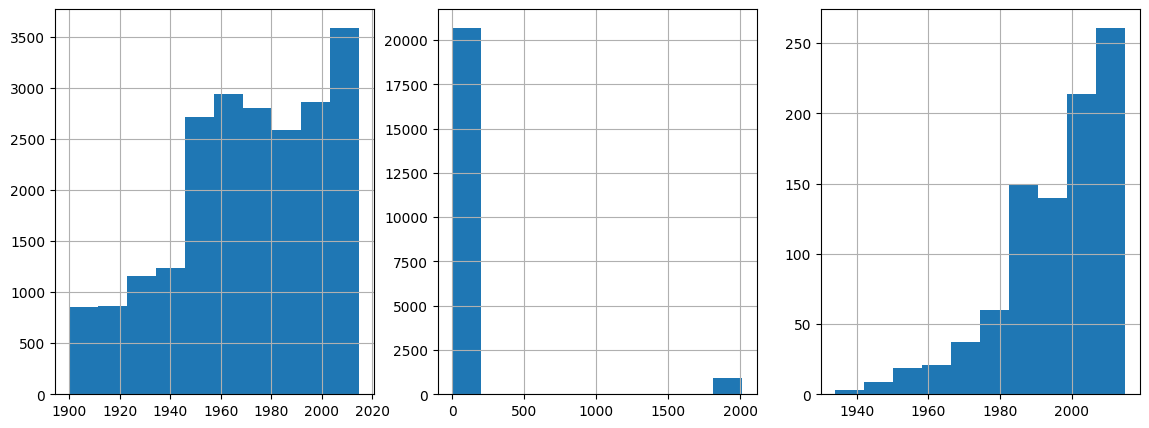

In [109]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

data["yr_built"].hist(ax=ax1)
data["yr_renovated"].hist(ax=ax2)
data["yr_renovated"][data["yr_renovated"] != 0].hist(ax=ax3)
plt.show()

In [97]:
data["yr_renovated"].value_counts()

yr_renovated
0       20699
2014       91
2013       37
2003       36
2005       35
        ...  
1951        1
1959        1
1948        1
1954        1
1944        1
Name: count, Length: 70, dtype: int64

In [103]:
data[(data["yr_built"] > data["yr_renovated"]) & (data["yr_renovated"] != 0)]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


In [106]:
len(data["yr_built"]), (data["yr_renovated"] != 0).sum()

(21613, 914)

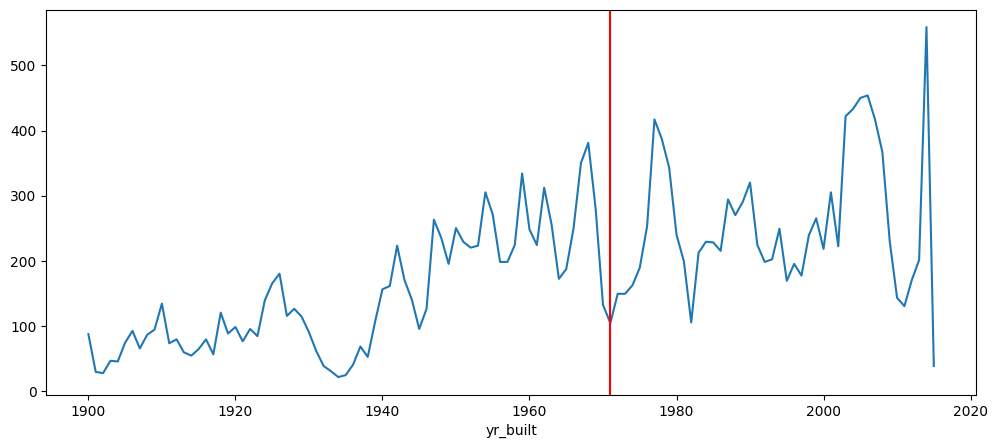

In [136]:
fig, ax = plt.subplots(figsize=(12, 5))
data["yr_built"].value_counts().sort_index().plot(ax=ax)
ax.axvline(x=1971, color="r")
plt.show()

В общем думал что попробую какую-то более умную гипотезу придумать учитывая yr_renovated, а там еще где пропущенные значения на самом деле, 0 стоит. В итоге просто примерно пополам поделил выборку по времени

In [137]:
(data["yr_built"] <= 1971).sum(), len(data)

(10285, 21613)

Средняя цена старого фонда: 4.0663
Средняя цена нового фонда: 4.0733


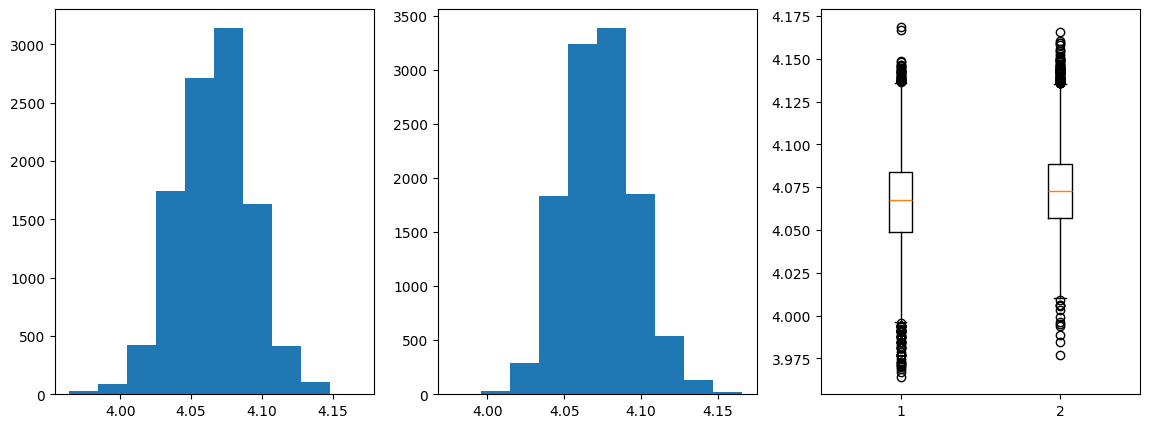

In [142]:
old_fund = data[data["yr_built"] <= 1971]["boxcox_price"]
new_fund = data[data["yr_built"] > 1971]["boxcox_price"]
print(f"Средняя цена старого фонда: {old_fund.mean():.4f}")
print(f"Средняя цена нового фонда: {new_fund.mean():.4f}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
ax1.hist(old_fund)
ax2.hist(new_fund)
ax3.boxplot([old_fund, new_fund])
plt.show()

In [144]:
print(lilliefors(old_fund), lilliefors(new_fund))

(0.022615199725655177, 0.0009999999999998899) (0.02342936408251134, 0.0009999999999998899)


In [ ]:
from scipy.stats import kstwobign


def two_sample_ks_test(sample1, sample2):
    n, m = len(sample1), len(sample2)
    sorted1, sorted2 = np.sort(sample1), np.sort(sample2)
    all_values = np.concatenate([sample1, sample2])
    all_values.sort()
    ecdf1 = np.searchsorted(sorted1, all_values, side="right") / n
    ecdf2 = np.searchsorted(sorted2, all_values, side="right") / m
    d_nm = np.max(np.abs(ecdf1 - ecdf2))
    coef = np.sqrt(n * m / (n + m))
    z = d_nm * coef
    p_value = 0
    for k in range(1, 101):
        p_value += 2 * (-1) ** (k - 1) * np.exp(-2 * k**2 * z**2)

    return d_nm, np.clip(p_value, 0, 1), kstwobign.ppf(0.95) / coef

In [ ]:
from scipy.stats import ks_2samp, cramervonmises_2samp, anderson_ksamp, mannwhitneyu

print(two_sample_ks_test(old_fund, new_fund))
print(ks_2samp(old_fund, new_fund))
print(cramervonmises_2samp(old_fund, new_fund), "skip")
result = anderson_ksamp([old_fund, new_fund])
print(result.statistic, "skip", result.critical_values[2])
# chi-square
n, m = len(old_fund), len(new_fund)
print(
    mannwhitneyu(old_fund, new_fund, alternative="two-sided"),
    n * m / 2 + stats.norm.ppf(0.975) * np.sqrt(n * m * (n + m + 1) / 12),
)

(0.11047914280574256, 1.4153995520494363e-57, 0.018497373785066284)
KstestResult(statistic=0.11047914280574256, pvalue=9.153102461763624e-58, statistic_location=4.048386378556814, statistic_sign=1)
CramerVonMisesResult(statistic=34.177629293804785, pvalue=6.132610641529368e-09) skip
279.74236299886167 skip 1.9609999999999999
MannwhitneyuResult(statistic=49649412.0, pvalue=1.0206078380069972e-78) 59152090.04706236


ну я как раз предполагал что новые дома дороже

# Задание 3

$H_0: independently~distributed$

$H_1: else$

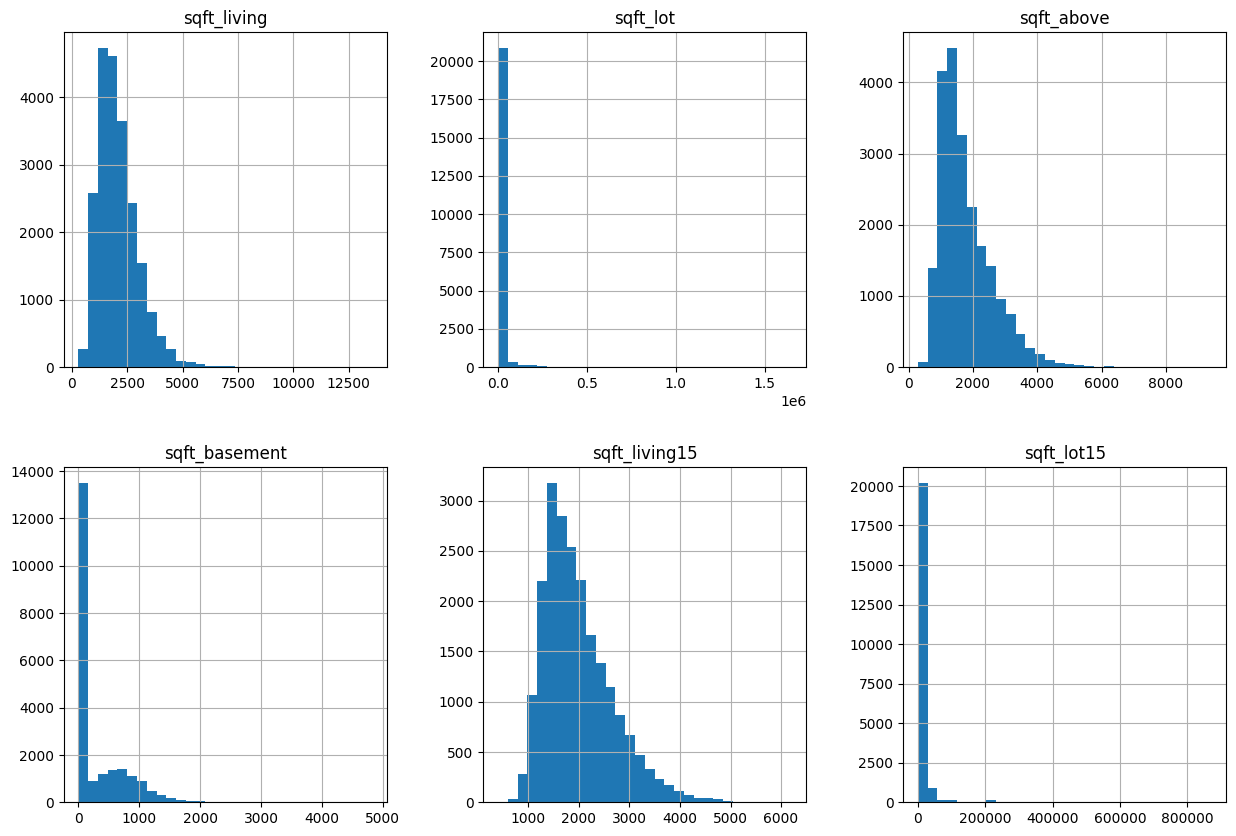

In [164]:
data[
    [
        "sqft_living",
        "sqft_lot",
        "sqft_above",
        "sqft_basement",
        "sqft_living15",
        "sqft_lot15",
    ]
].hist(bins=30, figsize=(15, 10), layout=(2, 3))

plt.show()

In [ ]:
(data["sqft_above"] + data["sqft_basement"] == data["sqft_living"]).sum() / len(data)

np.float64(1.0)

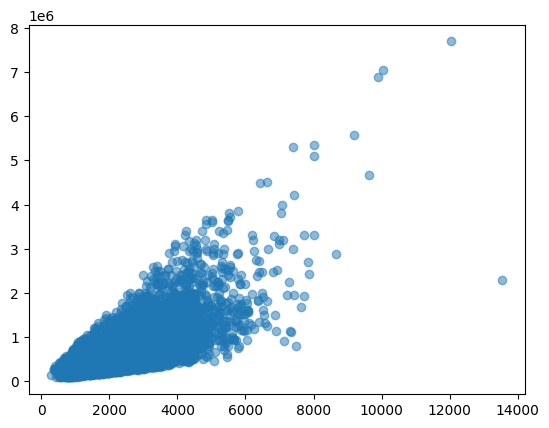

In [167]:
plt.scatter(data["sqft_living"], data["price"], alpha=0.5)
plt.show()

In [ ]:
from scipy.stats import t


def pearson_correlation_test(x, y):
    n = len(x)
    x_mean, y_mean = np.mean(x), np.mean(y)
    ro = np.sum((x - x_mean) * (y - y_mean)) / np.sqrt(
        np.sum((x - x_mean) ** 2) * np.sum((y - y_mean) ** 2)
    )
    t_stat = ro * np.sqrt((n - 2) / (1 - ro**2))
    df = n - 2
    return t_stat, 2 * (1 - t.cdf(abs(t_stat), df)), t.ppf(0.975, df)

In [179]:
from scipy.stats import spearmanr, kendalltau


print(pearson_correlation_test(data["sqft_living"], data["price"]))
result = spearmanr(data["sqft_living"], data["price"])
print(
    result.statistic * np.sqrt((n - 2) / (1 - result.statistic**2)),
    result.pvalue,
    t.ppf(0.975, df=n - 2),
)
result = kendalltau(data["sqft_living"], data["price"])
n = len(data)
print(
    result.statistic / np.sqrt(2 * (2 * n + 5) / (9 * n * (n - 1))),
    result.pvalue,
    norm.ppf(0.975),
)

(144.9203561982449, 0.0, 1.96007376205338)
123.81334766821618 0.0 1.96007376205338
102.22747305642912 0.0 1.959963984540054


В общем зависимость наглядная. Хотел тоже как-то попробовать разделить еще данные или исследовать от чего цена дополнительно зависит. Например на графике видно четко верхний ограничивающий наклон, интересная штука.